# INFO-F-422 — Statistical Foundations of Machine Learning
## Step 1 NARX Simulation 

This notebook contains the code for generating the NARX datasets.

### NARX1 Simulator

In [7]:
import numpy as np

def sim_narx1(N, noise, u=None):
    # init to zero (handles y(0)=0 automatically)
    y1 = np.zeros(N + 1)
    y2 = np.zeros(N + 1)
    
    # random input if none is provided
    if u is None:
        u = np.random.uniform(-1, 1, N + 1)
        
    std = np.sqrt(noise)
    w1 = np.random.normal(0, std, N + 1)
    w2 = np.random.normal(0, std, N + 1)

    # simulation loop (start at k=1 since we look 1 step back)
    for k in range(1, N):
        y1[k+1] = 0.5 * y2[k-1] + np.sin(y2[k]) + 0.3 * u[k-1] + w1[k+1]
        y2[k+1] = 0.5 * y1[k-1] + np.sin(y1[k]) + 0.2 * u[k] + w2[k+1]
        
    return u.reshape(-1, 1), np.column_stack((y1, y2))

### 2. NARX2 Simulator

In [8]:
def sim_narx2(N, noise, u=None):
    y1 = np.zeros(N + 1)
    y2 = np.zeros(N + 1)
    
    # handle 2d input
    if u is None:
        u = np.random.uniform(-1, 1, (N + 1, 2))
    
    u1, u2 = u[:, 0], u[:, 1]
    std = np.sqrt(noise)
    
    w1 = np.random.normal(0, std, N + 1)
    w2 = np.random.normal(0, std, N + 1)

    # start at k=2 because the formula looks 2 steps back
    for k in range(2, N):
        
        # calculate y1
        num1 = y1[k] * y1[k-1] * y1[k-2] * (y1[k-2] - 1) * u2[k-1] + u2[k]
        den1 = 1 + y2[k-1]**2 + y2[k-2]**2
        y1[k+1] = (num1 / den1) + w1[k+1]
        
        # calculate y2
        num2 = y2[k] * y2[k-1] * y2[k-2] * (y2[k-2] - 1) * u1[k-1] + u1[k]
        den2 = 1 + y1[k-1]**2 + y1[k-2]**2
        y2[k+1] = (num2 / den2) + w2[k+1]
        
    return u, np.column_stack((y1, y2))

### 3. Dataset Generation
Creating the controlled datasets to validate our upcoming models.

In [ ]:

# dataset generation  
N_train = 2000  
N_test = 1000   
noise = 0.05    

print("generating narx1 data...")
u_train_1, y_train_1 = sim_narx1(N_train, noise)
u_test_1, y_test_1   = sim_narx1(N_test, noise)

print(f"narx1 train : u {u_train_1.shape}, y {y_train_1.shape}")
print(f"narx1 test  : u {u_test_1.shape}, y {y_test_1.shape}")

print("\ngenerating narx2 data...")

# Stabilisation du système NARX 2 pr eviter les overflow
noise_narx2 = 0.0001
u_doux_train = np.random.uniform(-0.1, 0.1, (N_train + 1, 2))
u_doux_test = np.random.uniform(-0.1, 0.1, (N_test + 1, 2))

u_train_2, y_train_2 = sim_narx2(N_train, noise_narx2, u=u_doux_train)
u_test_2, y_test_2   = sim_narx2(N_test, noise_narx2, u=u_doux_test)

print(f"narx2 train : u {u_train_2.shape}, y {y_train_2.shape}")
print(f"narx2 test  : u {u_test_2.shape}, y {y_test_2.shape}")

generating narx1 data...
narx1 train : u (2001, 1), y (2001, 2)
narx1 test  : u (1001, 1), y (1001, 2)

generating narx2 data...
narx2 train : u (2001, 2), y (2001, 2)
narx2 test  : u (1001, 2), y (1001, 2)


### 4. Data Visualization 
Plotting the first 500 steps to visually check the simulation and system dynamics.


plotting time series...


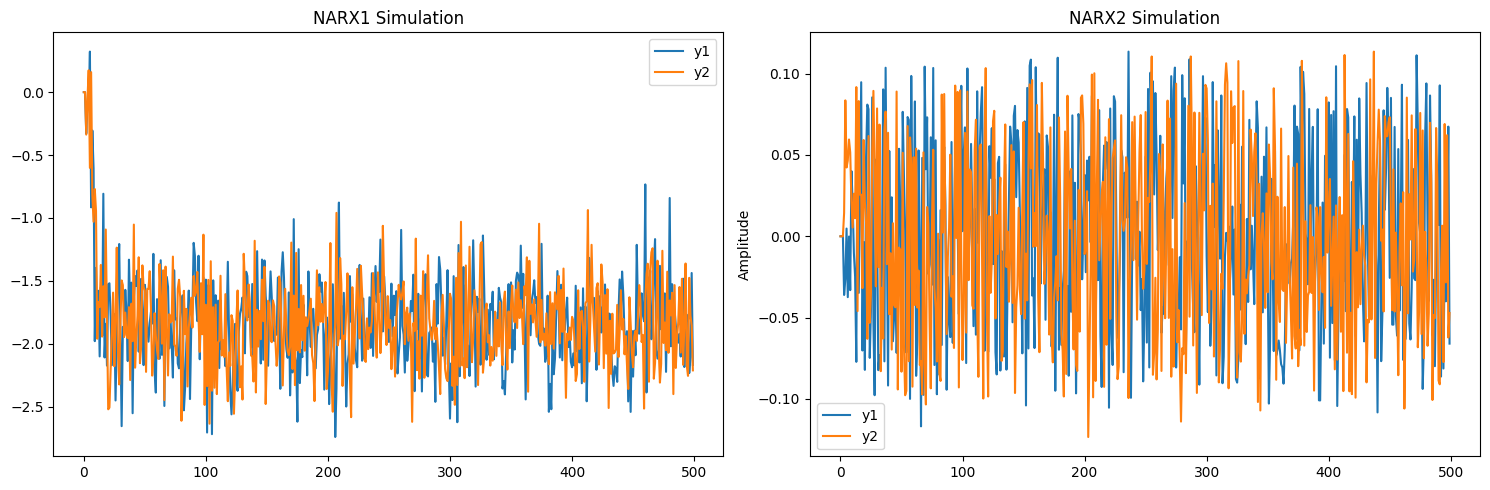

In [11]:
import matplotlib.pyplot as plt

# plot first 500 steps to visually check the simulation
print("\nplotting time series...")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# narx1 plot
axes[0].plot(y_train_1[:500, 0], label='y1')
axes[0].plot(y_train_1[:500, 1], label='y2')
axes[0].set_title('NARX1 Simulation')
axes[0].legend()

# narx2 plot
axes[1].plot(y_train_2[:500, 0], label='y1')
axes[1].plot(y_train_2[:500, 1], label='y2')
axes[1].set_title('NARX2 Simulation')
axes[1].set_ylabel('Amplitude')
axes[1].legend()

plt.tight_layout()
plt.show()